In [88]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple, Optional

In [89]:
# ============================================================
# CONFIGURATION
# ============================================================

# Data directories
RESULTS_DIR_DISC = Path("results")
RESULTS_DIR_CONT = Path("results_2nd_order")

# Problem parameters
THETA0 = -1.5
THETA_STAR = 1.0
C_VALUE = 0.0

# Optimizer parameters
BETA1 = 0.99
BETA2 = 0.999
V0_TARGET = 1.0
MAX_LR = 0.1

# Analysis parameters
SUBSTEP_FACTOR = 5           # substeps in 2nd order: dt = alpha / SUBSTEP_FACTOR
TAIL_WINDOW_TIME = 1.7       # final window in physical time for estimating B
DELTA_TIME = 1.0             # initial layer to discard in bound fitting
ENVELOPE_WINDOW_TIME = 0.1   # window for envelope computation
LR_SHOW = 0.001                # learning rate to visualize in detail

# Constants
EPS = 1e-16                  # to avoid log(0) in plots

In [90]:
# ============================================================
# CORE FUNCTIONS
# ============================================================

def f_rosenbrock(theta: np.ndarray, c: float = 1.5) -> np.ndarray:
    """Generalized Rosenbrock function."""
    return (1 - theta)**2 + c * (theta**2 - 1)**2


def compute_rho(alpha: float, beta1: float, beta2: float) -> float:
    """Compute rho = max(alpha, (alpha/(1-beta1))^2, alpha/(1-beta2))."""
    return max(alpha, (alpha / (1 - beta1))**2, alpha / (1 - beta2))


def dt_of(kind: str, lr: float) -> float:
    """Return physical time step based on simulation type."""
    return lr if kind == "disc" else lr / SUBSTEP_FACTOR


def t_end_of(theta: np.ndarray, kind: str, lr: float) -> float:
    """Calculate final physical time of the simulation."""
    return (len(theta) - 1) * dt_of(kind, lr)


def make_t_phi(theta: np.ndarray, kind: str, lr: float, c_value: float, f_star: float) -> Tuple[np.ndarray, np.ndarray]:
    """Create time and phi(t) = f(theta(t)) - f_star arrays."""
    dt = dt_of(kind, lr)
    t = np.arange(len(theta)) * dt
    phi = f_rosenbrock(theta, c=c_value) - f_star
    return t, phi

In [91]:
# ============================================================
# FILE PARSING AND FILTERING
# ============================================================

def extract_params(filename: str) -> Optional[Dict]:
    """
    Extract parameters from filename.
    
    Handles two formats:
    - Discrete: c_X.X_results_initial_theta_Y_lr_Z_beta1_W_beta2_V.csv
    - 2nd order: second_order_c_X.X_initial_theta_Y_initial_velocity_Z_lr_W_beta1_V_beta2_U.csv
    """
    # Try discrete format
    m = re.search(
        r'c_([\d.]+)_results_initial_theta_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if m:
        return dict(
            kind="disc",
            c=float(m[1]),
            th0=float(m[2]),
            lr=float(m[3]),
            b1=float(m[4]),
            b2=float(m[5]),
            v0=None
        )

    # Try 2nd order format
    m = re.search(
        r'second_order_c_([\d.]+)_initial_theta_([-\d.]+)_initial_velocity_([-\d.]+)_lr_([\d.]+)_beta1_([\d.]+)_beta2_([\d.]+)\.csv',
        filename
    )
    if m:
        return dict(
            kind="cont",
            c=float(m[1]),
            th0=float(m[2]),
            v0=float(m[3]),
            lr=float(m[4]),
            b1=float(m[5]),
            b2=float(m[6])
        )
    
    return None


def accept(prm: Optional[Dict]) -> bool:
    """Check if parameters match the configuration filters."""
    tol = 1e-12
    
    if prm is None:
        return False
    
    # Check all parameters match configuration
    if abs(prm["c"] - C_VALUE) > tol:
        return False
    if abs(prm["th0"] - THETA0) > tol:
        return False
    if abs(prm["b1"] - BETA1) > tol or abs(prm["b2"] - BETA2) > tol:
        return False
    if prm["kind"] == "cont" and abs(prm["v0"] - V0_TARGET) > tol:
        return False
    if prm["lr"] > MAX_LR:
        return False
    
    return True


def read_theta_series(csv_path: Path, kind: str) -> np.ndarray:
    """Read theta time series from CSV file."""
    df = pd.read_csv(csv_path)
    return df["theta_history"].to_numpy()

In [92]:
# ============================================================
# ENVELOPE AND BOUND FUNCTIONS
# ============================================================

def upper_envelope(t: np.ndarray, y: np.ndarray, w_time: float) -> np.ndarray:
    """Compute running maximum in a physical time window."""
    if len(t) < 3:
        return y.copy()
    
    dt = float(np.mean(np.diff(t)))
    w = max(3, int(w_time / dt))
    env = np.empty_like(y)
    
    for i in range(len(y)):
        j0 = max(0, i - w)
        env[i] = np.max(y[j0:i+1])
    
    return env


def fit_rate_omega(
    t: np.ndarray,
    env: np.ndarray,
    B: float,
    delta: float,
    t_fit_end: float
) -> Optional[float]:
    """
    Fit omega using linear regression to log(env - B) in [delta, t_fit_end].
    
    Returns omega such that env ~ A exp(-omega * (t - delta)) + B
    """
    mask = (t >= delta) & (t <= t_fit_end)
    residual = env[mask] - B
    mask2 = residual > 0
    
    t2 = t[mask][mask2]
    r2 = residual[mask2]
    
    if len(r2) < 5:
        return None
    
    X = t2 - delta
    Y = np.log(r2)
    A = np.vstack([np.ones_like(X), X]).T
    a0, slope = np.linalg.lstsq(A, Y, rcond=None)[0]
    omega = -float(slope)
    
    return omega


def build_bound(
    t: np.ndarray,
    env: np.ndarray,
    delta: float,
    B: float,
    omega: float
) -> Tuple[float, np.ndarray]:
    """
    Build bound A exp(-omega * (t - delta)) + B that upper bounds env(t).
    
    Returns:
        A: Amplitude coefficient
        ub: Upper bound array
    """
    mask = t >= delta
    residual = env[mask] - B
    residual = np.maximum(residual, 0.0)
    A = float(np.max(residual * np.exp(omega * (t[mask] - delta))))
    ub = A * np.exp(-omega * (t - delta)) + B
    
    return A, ub

In [93]:
# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_one(
    lr: float,
    disc_by_lr: Dict[float, Path],
    cont_by_lr: Dict[float, Path],
    delta_time: float,
    envelope_window_time: float,
    tail_window_time: float,
    c_value: float,
    f_star: float
) -> Dict[str, Dict]:
    """
    Validate exponential bound for a specific learning rate.
    
    Computes envelope, fits omega, and checks bound violations
    for both discrete and continuous simulations.
    
    Returns:
        Dictionary with results for "disc" and "cont" keys
    """
    out = {}
    
    for kind, path in [("disc", disc_by_lr[lr]), ("cont", cont_by_lr[lr])]:
        # Load data
        theta = read_theta_series(path, kind)
        t, phi = make_t_phi(theta, kind, lr, c_value, f_star)
        y = np.maximum(phi, EPS)
        
        # Compute envelope
        env = upper_envelope(t, y, envelope_window_time)
        
        # Define T_end and tail (use MAX in tail for bound B)
        T_end = float(t[-1])
        t0 = max(T_end - tail_window_time, 0.0)
        tail = env[t >= t0]
        B = float(np.max(tail)) if len(tail) else float(env[-1])
        
        # Fit omega (use section before tail)
        t_fit_end = max(delta_time + 1e-6, T_end - tail_window_time)
        omega = fit_rate_omega(t, env, B, delta_time, t_fit_end)
        if omega is None or omega <= 0:
            omega = 1e-6  # fallback (bound will be loose)
        
        # Build bound
        A, ub = build_bound(t, env, delta_time, B, omega)
        
        # Check violations
        viol = env - ub
        max_viol = float(np.max(viol))
        frac_viol = float(np.mean(viol > 1e-12))
        
        out[kind] = dict(
            t=t,
            phi=y,
            env=env,
            B=B,
            omega=omega,
            A=A,
            ub=ub,
            max_viol=max_viol,
            frac_viol=frac_viol,
            T_end=T_end
        )
    
    return out

In [94]:
# ============================================================
# COMPUTE OPTIMAL VALUE
# ============================================================

f_star = f_rosenbrock(THETA_STAR, c=C_VALUE)
print(f"f_star = f(theta_star={THETA_STAR}) = {f_star:.6e}")

f_star = f(theta_star=1.0) = 0.000000e+00


In [95]:
# ============================================================
# BUILD LR-INDEXED DICTIONARIES
# ============================================================

disc_by_lr = {}
cont_by_lr = {}

for folder, kind, dict_ref in [(RESULTS_DIR_DISC, "disc", disc_by_lr),
                                (RESULTS_DIR_CONT, "cont", cont_by_lr)]:
    for p in folder.glob("*.csv"):
        prm = extract_params(p.name)
        if accept(prm) and prm["kind"] == kind:
            dict_ref[prm["lr"]] = p

print(f"\nFound {len(disc_by_lr)} discrete and {len(cont_by_lr)} continuous learning rates")
print(f"Available learning rates: {sorted(set(disc_by_lr.keys()) & set(cont_by_lr.keys()))}")


Found 6 discrete and 6 continuous learning rates
Available learning rates: [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]


In [96]:
# ============================================================
# VALIDATE EXPONENTIAL BOUND FOR ONE LEARNING RATE
# ============================================================

res = validate_one(
    LR_SHOW,
    disc_by_lr,
    cont_by_lr,
    DELTA_TIME,
    ENVELOPE_WINDOW_TIME,
    TAIL_WINDOW_TIME,
    C_VALUE,
    f_star
)

rho = compute_rho(LR_SHOW, BETA1, BETA2)
print(f"\n{'='*70}")
print(f"VALIDATION RESULTS FOR lr={LR_SHOW}")
print(f"{'='*70}")
print(f"rho = {rho:.6g}")
print(f"rho^2 = {rho**2:.3e}\n")

for kind in ["disc", "cont"]:
    r = res[kind]
    print(f"{kind.upper():6s}:")
    print(f"  T_end       = {r['T_end']:.3f}")
    print(f"  B (floor)   = {r['B']:.6e}")
    print(f"  omega (rate)= {r['omega']:.6e}")
    print(f"  A (ampli)   = {r['A']:.6e}")
    print(f"  max_viol    = {r['max_viol']:.6e}")
    print(f"  frac_viol   = {r['frac_viol']:.6e}")
    print()


VALIDATION RESULTS FOR lr=0.001
rho = 1
rho^2 = 1.000e+00

DISC  :
  T_end       = 5.999
  B (floor)   = 1.351972e-03
  omega (rate)= 2.332687e+00
  A (ampli)   = 1.304846e+01
  max_viol    = 0.000000e+00
  frac_viol   = 0.000000e+00

CONT  :
  T_end       = 5.999
  B (floor)   = 1.369918e-03
  omega (rate)= 2.331990e+00
  A (ampli)   = 1.309745e+01
  max_viol    = 0.000000e+00
  frac_viol   = 0.000000e+00



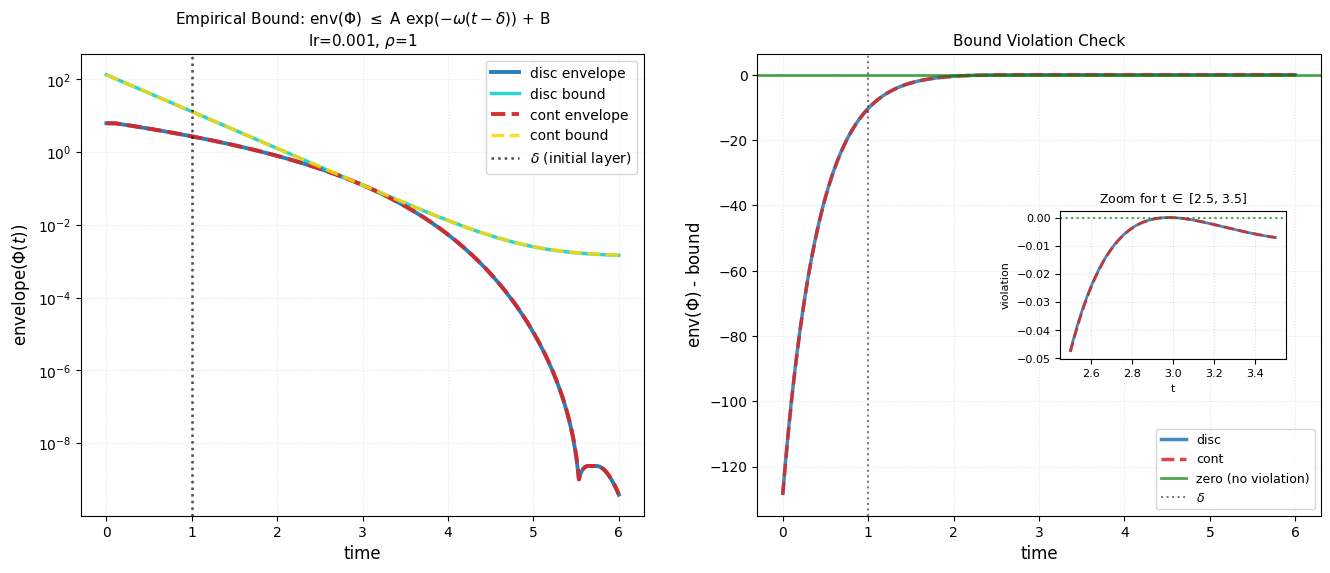

In [115]:
# ============================================================
# PLOT: ENVELOPE AND BOUND VALIDATION
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define distinct color pairs: (envelope_color, bound_color)
colors = {
    "disc": ("#1f77b4", "#00CED1"),      # dark blue, cyan
    "cont": ("#d62728", "#FFD700")       # red, gold
}

# Left plot: Envelope and Bound (NO ZOOM)
for kind, ls in [("disc", "-"), ("cont", "--")]:
    r = res[kind]
    env_color, bound_color = colors[kind]
    
    ax1.semilogy(r["t"], r["env"], ls, lw=2.8, alpha=0.95, 
                 color=env_color, label=f"{kind} envelope")
    ax1.semilogy(r["t"], np.maximum(r["ub"], EPS), ls, lw=2.5, alpha=0.85, 
                 color=bound_color, label=f"{kind} bound")

ax1.axvline(DELTA_TIME, color="black", ls=":", lw=1.8, alpha=0.7, 
            label=r"$\delta$ (initial layer)")
ax1.grid(True, which="both", ls=":", alpha=0.3)
ax1.set_xlabel("time", fontsize=12)
ax1.set_ylabel(r"envelope($\Phi(t)$)", fontsize=12)
ax1.set_title(
    fr"Empirical Bound: env($\Phi$) $\leq$ A exp($-\omega(t-\delta)$) + B" "\n"
    fr"lr={LR_SHOW}, $\rho$={rho:.3g}",
    fontsize=11
)
ax1.legend(fontsize=10, loc='best')

# Right plot: Violation with zoom between t=2.5 and t=3.5
for kind, ls in [("disc", "-"), ("cont", "--")]:
    r = res[kind]
    viol = r["env"] - r["ub"]
    env_color, _ = colors[kind]
    ax2.plot(r["t"], viol, ls, lw=2.5, alpha=0.85, color=env_color, label=f"{kind}")

ax2.axhline(0, color="green", ls="-", lw=2, alpha=0.7, label="zero (no violation)")
ax2.axvline(DELTA_TIME, color="black", ls=":", lw=1.5, alpha=0.5, label=r"$\delta$")
ax2.grid(True, which="both", ls=":", alpha=0.3)
ax2.set_xlabel("time", fontsize=12)
ax2.set_ylabel(r"env($\Phi$) - bound", fontsize=12)
ax2.set_title("Bound Violation Check", fontsize=11)
ax2.legend(fontsize=9, loc='lower right')

# Add inset zoom for violation between t=2.5 and t=3.5 - repositioned to center right
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins2 = inset_axes(ax2, width="40%", height="32%", loc='center right', 
                    bbox_to_anchor=(-0.05, 0, 1, 1), bbox_transform=ax2.transAxes)

t_zoom2_start = 2.5
t_zoom2_end = 3.5
for kind, ls in [("disc", "-"), ("cont", "--")]:
    r = res[kind]
    viol = r["env"] - r["ub"]
    env_color, _ = colors[kind]
    mask_zoom = (r["t"] >= t_zoom2_start) & (r["t"] <= t_zoom2_end)
    axins2.plot(r["t"][mask_zoom], viol[mask_zoom], ls, lw=2.0, 
                color=env_color, alpha=0.85)

axins2.axhline(0, color="green", ls=":", lw=1.5, alpha=0.7)
axins2.grid(True, alpha=0.4, ls=":")
axins2.set_title(fr"Zoom for t $\in$ [{t_zoom2_start}, {t_zoom2_end}]", fontsize=9)
axins2.set_xlabel("t", fontsize=8)
axins2.set_ylabel("violation", fontsize=8)
axins2.tick_params(labelsize=8)